In [348]:
import pandas as pd

df = pd.read_csv("dados_satisfacao (1).csv")

df





,cliente_id,satisfacao_geral_01-2024,satisfacao_geral_02-2024,satisfacao_geral_03-2024,satisfacao_produto_01-2024,satisfacao_produto_02-2024,satisfacao_produto_03-2024,satisfacao_servico_01-2024,satisfacao_servico_02-2024,satisfacao_servico_03-2024,idade,genero
0,1,4,3,4,5,4,4,3,4,4,25,F
1,2,5,2,4,4,5,4,4,2,4,35,M
2,3,3,1,3,4,3,5,3,2,5,45,F
3,4,4,4,5,3,5,5,4,5,3,28,M
4,5,4,4,4,4,3,4,3,4,4,38,F
5,6,5,2,4,4,4,5,5,4,5,48,M
6,7,3,4,5,5,4,4,4,5,4,30,F
7,8,4,4,3,4,5,3,5,4,4,40,M
8,9,5,3,4,5,4,4,4,3,5,50,F
9,10,3,4,5,4,3,5,2,3,4,32,M


In [349]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   cliente_id                  10 non-null     int64
 1   satisfacao_geral_01-2024    10 non-null     int64
 2   satisfacao_geral_02-2024    10 non-null     int64
 3   satisfacao_geral_03-2024    10 non-null     int64
 4   satisfacao_produto_01-2024  10 non-null     int64
 5   satisfacao_produto_02-2024  10 non-null     int64
 6   satisfacao_produto_03-2024  10 non-null     int64
 7   satisfacao_servico_01-2024  10 non-null     int64
 8   satisfacao_servico_02-2024  10 non-null     int64
 9   satisfacao_servico_03-2024  10 non-null     int64
 10  idade                       10 non-null     int64
 11  genero                      10 non-null     str  
dtypes: int64(11), str(1)
memory usage: 1.1 KB


In [350]:
df_melt = pd.melt(
    df,
    id_vars=["cliente_id", "idade", "genero"],
    value_vars=[
        "satisfacao_geral_01-2024",
        "satisfacao_geral_02-2024",
        "satisfacao_geral_03-2024",
        "satisfacao_produto_01-2024",
        "satisfacao_produto_02-2024",
        "satisfacao_produto_03-2024",
        "satisfacao_servico_01-2024",
        "satisfacao_servico_02-2024",
        "satisfacao_servico_03-2024",
    ],
    var_name="categoria_mes",
    value_name="nota"
)

display(df_melt)

,cliente_id,idade,genero,categoria_mes,nota
0,1,25,F,satisfacao_geral_01-2024,4
1,2,35,M,satisfacao_geral_01-2024,5
2,3,45,F,satisfacao_geral_01-2024,3
3,4,28,M,satisfacao_geral_01-2024,4
4,5,38,F,satisfacao_geral_01-2024,4
...,...,...,...,...,...
85,6,48,M,satisfacao_servico_03-2024,5
86,7,30,F,satisfacao_servico_03-2024,4
87,8,40,M,satisfacao_servico_03-2024,4
88,9,50,F,satisfacao_servico_03-2024,5


In [351]:
df_melt.head(25)
# head vai trazer as 25 primeiras linhas

,cliente_id,idade,genero,categoria_mes,nota
0,1,25,F,satisfacao_geral_01-2024,4
1,2,35,M,satisfacao_geral_01-2024,5
2,3,45,F,satisfacao_geral_01-2024,3
3,4,28,M,satisfacao_geral_01-2024,4
4,5,38,F,satisfacao_geral_01-2024,4
5,6,48,M,satisfacao_geral_01-2024,5
6,7,30,F,satisfacao_geral_01-2024,3
7,8,40,M,satisfacao_geral_01-2024,4
8,9,50,F,satisfacao_geral_01-2024,5
9,10,32,M,satisfacao_geral_01-2024,3


In [352]:
df_melt.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   cliente_id     90 non-null     int64
 1   idade          90 non-null     int64
 2   genero         90 non-null     str  
 3   categoria_mes  90 non-null     str  
 4   nota           90 non-null     int64
dtypes: int64(3), str(2)
memory usage: 3.6 KB


In [353]:
# O .str serve para trabalhar com texto (strings) dentro de uma coluna do DataFrame.
# .str = "quero mexer com textos dessa coluna"

# O split dividir um texto
# Muito usado quando uma informação vem junta e você quer separar.


df_melt[["categoria", "mes"]]= df_melt["categoria_mes"].str.rsplit("_", n=1, expand=True)
display(df_melt)

,cliente_id,idade,genero,categoria_mes,nota,categoria,mes
0,1,25,F,satisfacao_geral_01-2024,4,satisfacao_geral,01-2024
1,2,35,M,satisfacao_geral_01-2024,5,satisfacao_geral,01-2024
2,3,45,F,satisfacao_geral_01-2024,3,satisfacao_geral,01-2024
3,4,28,M,satisfacao_geral_01-2024,4,satisfacao_geral,01-2024
4,5,38,F,satisfacao_geral_01-2024,4,satisfacao_geral,01-2024
...,...,...,...,...,...,...,...
85,6,48,M,satisfacao_servico_03-2024,5,satisfacao_servico,03-2024
86,7,30,F,satisfacao_servico_03-2024,4,satisfacao_servico,03-2024
87,8,40,M,satisfacao_servico_03-2024,4,satisfacao_servico,03-2024
88,9,50,F,satisfacao_servico_03-2024,5,satisfacao_servico,03-2024


In [354]:
# REMOVENDO A COLUNA DE CATEGORIA_MES USANDO DROP QUE ELE EXCLUI/ REMOVE 

df_melt = df_melt.drop(columns=["categoria_mes"])
display(df_melt)

,cliente_id,idade,genero,nota,categoria,mes
0,1,25,F,4,satisfacao_geral,01-2024
1,2,35,M,5,satisfacao_geral,01-2024
2,3,45,F,3,satisfacao_geral,01-2024
3,4,28,M,4,satisfacao_geral,01-2024
4,5,38,F,4,satisfacao_geral,01-2024
...,...,...,...,...,...,...
85,6,48,M,5,satisfacao_servico,03-2024
86,7,30,F,4,satisfacao_servico,03-2024
87,8,40,M,4,satisfacao_servico,03-2024
88,9,50,F,5,satisfacao_servico,03-2024


In [355]:
df_melt.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   cliente_id  90 non-null     int64
 1   idade       90 non-null     int64
 2   genero      90 non-null     str  
 3   nota        90 non-null     int64
 4   categoria   90 non-null     str  
 5   mes         90 non-null     str  
dtypes: int64(3), str(3)
memory usage: 4.3 KB


In [356]:
# O Y maiúsculo é para indicar que o ano tem 4 números 
# O y minúsculo é para indicar que o ano tem 2 números 

df_melt["mes"] = pd.to_datetime(df_melt["mes"], format="%m-%Y")
display(df_melt)

,cliente_id,idade,genero,nota,categoria,mes
0,1,25,F,4,satisfacao_geral,2024-01-01
1,2,35,M,5,satisfacao_geral,2024-01-01
2,3,45,F,3,satisfacao_geral,2024-01-01
3,4,28,M,4,satisfacao_geral,2024-01-01
4,5,38,F,4,satisfacao_geral,2024-01-01
...,...,...,...,...,...,...
85,6,48,M,5,satisfacao_servico,2024-03-01
86,7,30,F,4,satisfacao_servico,2024-03-01
87,8,40,M,4,satisfacao_servico,2024-03-01
88,9,50,F,5,satisfacao_servico,2024-03-01


In [357]:
df_melt.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   cliente_id  90 non-null     int64         
 1   idade       90 non-null     int64         
 2   genero      90 non-null     str           
 3   nota        90 non-null     int64         
 4   categoria   90 non-null     str           
 5   mes         90 non-null     datetime64[us]
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 4.3 KB


In [358]:
df_melt["mes"] = df_melt["mes"].dt.month
display(df_melt)

,cliente_id,idade,genero,nota,categoria,mes
0,1,25,F,4,satisfacao_geral,1
1,2,35,M,5,satisfacao_geral,1
2,3,45,F,3,satisfacao_geral,1
3,4,28,M,4,satisfacao_geral,1
4,5,38,F,4,satisfacao_geral,1
...,...,...,...,...,...,...
85,6,48,M,5,satisfacao_servico,3
86,7,30,F,4,satisfacao_servico,3
87,8,40,M,4,satisfacao_servico,3
88,9,50,F,5,satisfacao_servico,3


In [359]:
df_melt.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   cliente_id  90 non-null     int64
 1   idade       90 non-null     int64
 2   genero      90 non-null     str  
 3   nota        90 non-null     int64
 4   categoria   90 non-null     str  
 5   mes         90 non-null     int32
dtypes: int32(1), int64(3), str(2)
memory usage: 4.0 KB


In [360]:
df_melt["genero"]= df_melt["genero"].astype("category")
df_melt["categoria"]=df_melt["categoria"].astype("category")
display(df_melt)

,cliente_id,idade,genero,nota,categoria,mes
0,1,25,F,4,satisfacao_geral,1
1,2,35,M,5,satisfacao_geral,1
2,3,45,F,3,satisfacao_geral,1
3,4,28,M,4,satisfacao_geral,1
4,5,38,F,4,satisfacao_geral,1
...,...,...,...,...,...,...
85,6,48,M,5,satisfacao_servico,3
86,7,30,F,4,satisfacao_servico,3
87,8,40,M,4,satisfacao_servico,3
88,9,50,F,5,satisfacao_servico,3


In [361]:
df_melt.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cliente_id  90 non-null     int64   
 1   idade       90 non-null     int64   
 2   genero      90 non-null     category
 3   nota        90 non-null     int64   
 4   categoria   90 non-null     category
 5   mes         90 non-null     int32   
dtypes: category(2), int32(1), int64(3)
memory usage: 2.8 KB


In [362]:
df_melt.groupby(["categoria","mes"])["nota"].mean()


categoria           mes
satisfacao_geral    1      4.0
                    2      3.1
                    3      4.1
satisfacao_produto  1      4.2
                    2      4.0
                    3      4.3
satisfacao_servico  1      3.7
                    2      3.6
                    3      4.2
Name: nota, dtype: float64

In [363]:
# DESCRIBE () 
# Ele serve para mostrar um resumo estatístico rápido dos seus dados
# É como se você perguntasse ao Pandas: "Me dá um resumo dessa tabela."

df_melt.groupby(["categoria", "mes"])["nota"].describe()


count  mean       std  min   25%  50%   75%  max
categoria          mes                                                  
satisfacao_geral   1     10.0   4.0  0.816497  3.0  3.25  4.0  4.75  5.0
                   2     10.0   3.1  1.100505  1.0  2.25  3.5  4.00  4.0
                   3     10.0   4.1  0.737865  3.0  4.00  4.0  4.75  5.0
satisfacao_produto 1     10.0   4.2  0.632456  3.0  4.00  4.0  4.75  5.0
                   2     10.0   4.0  0.816497  3.0  3.25  4.0  4.75  5.0
                   3     10.0   4.3  0.674949  3.0  4.00  4.0  5.00  5.0
satisfacao_servico 1     10.0   3.7  0.948683  2.0  3.00  4.0  4.00  5.0
                   2     10.0   3.6  1.074968  2.0  3.00  4.0  4.00  5.0
                   3     10.0   4.2  0.632456  3.0  4.00  4.0  4.75  5.0

<Axes: xlabel='categoria', ylabel='nota'>

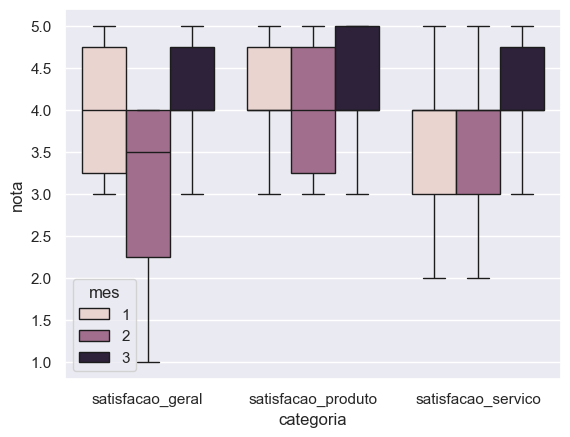

In [364]:
# O Seaborn é uma biblioteca do Python usada para criar gráficos bonitos e mais profissionais, principalmente para análise de dados 

import seaborn as sns

sns.set_theme()

sns.boxplot(data=df_melt, x="categoria", y="nota", hue="mes")